# GitHub Tech Trends — Final Report

**Project overview**: Analysis of GitHub language adoption, developer migration patterns,
forecasting, and community structure using 2015–2024 GitHub Archive data.

| Deliverable | Description | Rows |
|-------------|-------------|------|
| D1 | Monthly language metrics + KMeans clustering | 43,016 / 468 |
| D2 | ARIMA + Prophet 24-month forecasts | 4,191 |
| D3 | Technology migration graph (edges + nodes) | 42 / 39 |
| D4 | Developer PageRank + HITS | 10,000 |
| D5 | Leiden community detection | 10,000 |

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid', palette='tab10')
print('Environment ready.')

Environment ready.


## Load all datasets

In [2]:
d1_monthly   = pd.read_parquet(f'gs://{BUCKET}/processed/d1_monthly/')
d1_clusters  = pd.read_parquet(f'gs://{BUCKET}/processed/d1_clusters/')
d2_forecasts = pd.read_parquet(f'gs://{BUCKET}/processed/d2_forecasts/')
d3_edges     = pd.read_parquet(f'gs://{BUCKET}/processed/d3_edges/')
d3_nodes     = pd.read_parquet(f'gs://{BUCKET}/processed/d3_nodes/')
d4_pagerank  = pd.read_parquet(f'gs://{BUCKET}/processed/d4_pagerank/')
d5_comms     = pd.read_parquet(f'gs://{BUCKET}/processed/d5_communities/')

d1_monthly['date']   = pd.to_datetime(d1_monthly['year_month']   + '-01')
d2_forecasts['date'] = pd.to_datetime(d2_forecasts['year_month'] + '-01')

print('All datasets loaded.')

All datasets loaded.


---
## Part 1 — D1: Language Landscape

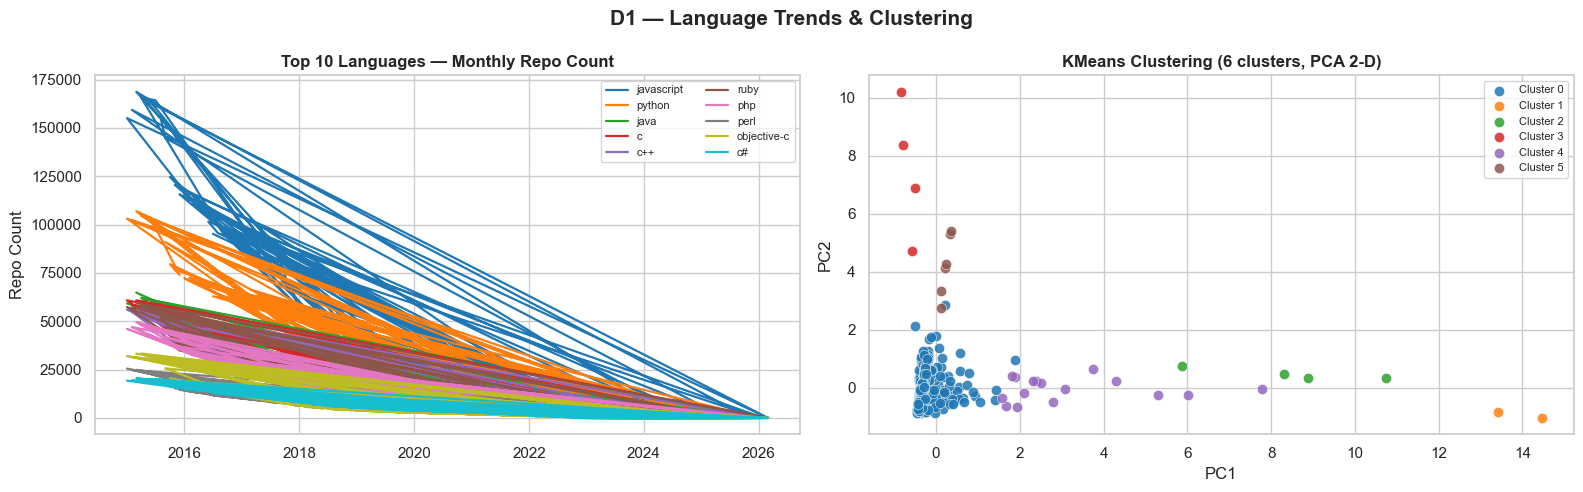

→ 468 languages tracked  |  2015-01-01 – 2026-03-01


In [3]:
top_langs = (
    d1_monthly.groupby('language')['repo_count'].mean()
    .sort_values(ascending=False).head(10).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Time series ---
colors = plt.cm.tab10.colors
ax = axes[0]
for i, lang in enumerate(top_langs):
    sub = d1_monthly[d1_monthly['language'] == lang]
    ax.plot(sub['date'], sub['repo_count'], label=lang,
            color=colors[i], linewidth=1.6)
ax.set_title('Top 10 Languages — Monthly Repo Count', fontweight='bold')
ax.set_ylabel('Repo Count')
ax.legend(fontsize=8, ncol=2)

# --- Cluster PCA ---
feature_cols = ['avg_bytes_growth', 'commit_volatility', 'bytes_range_ratio',
                'avg_repo_count', 'avg_commit_count']
X = StandardScaler().fit_transform(d1_clusters[feature_cols].fillna(0))
coords = PCA(n_components=2, random_state=42).fit_transform(X)
ax = axes[1]
palette = sns.color_palette('tab10', d1_clusters['cluster'].nunique())
for i, c in enumerate(sorted(d1_clusters['cluster'].unique())):
    mask = d1_clusters['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {c}',
               color=palette[i], s=55, alpha=0.85, edgecolors='white', linewidths=0.4)
ax.set_title(f'KMeans Clustering ({d1_clusters["cluster"].nunique()} clusters, PCA 2-D)',
             fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8)

plt.suptitle('D1 — Language Trends & Clustering', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_d1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ {d1_monthly["language"].nunique()} languages tracked  |  '
      f'{d1_monthly["date"].min().date()} – {d1_monthly["date"].max().date()}')

---
## Part 2 — D2: Forecasting

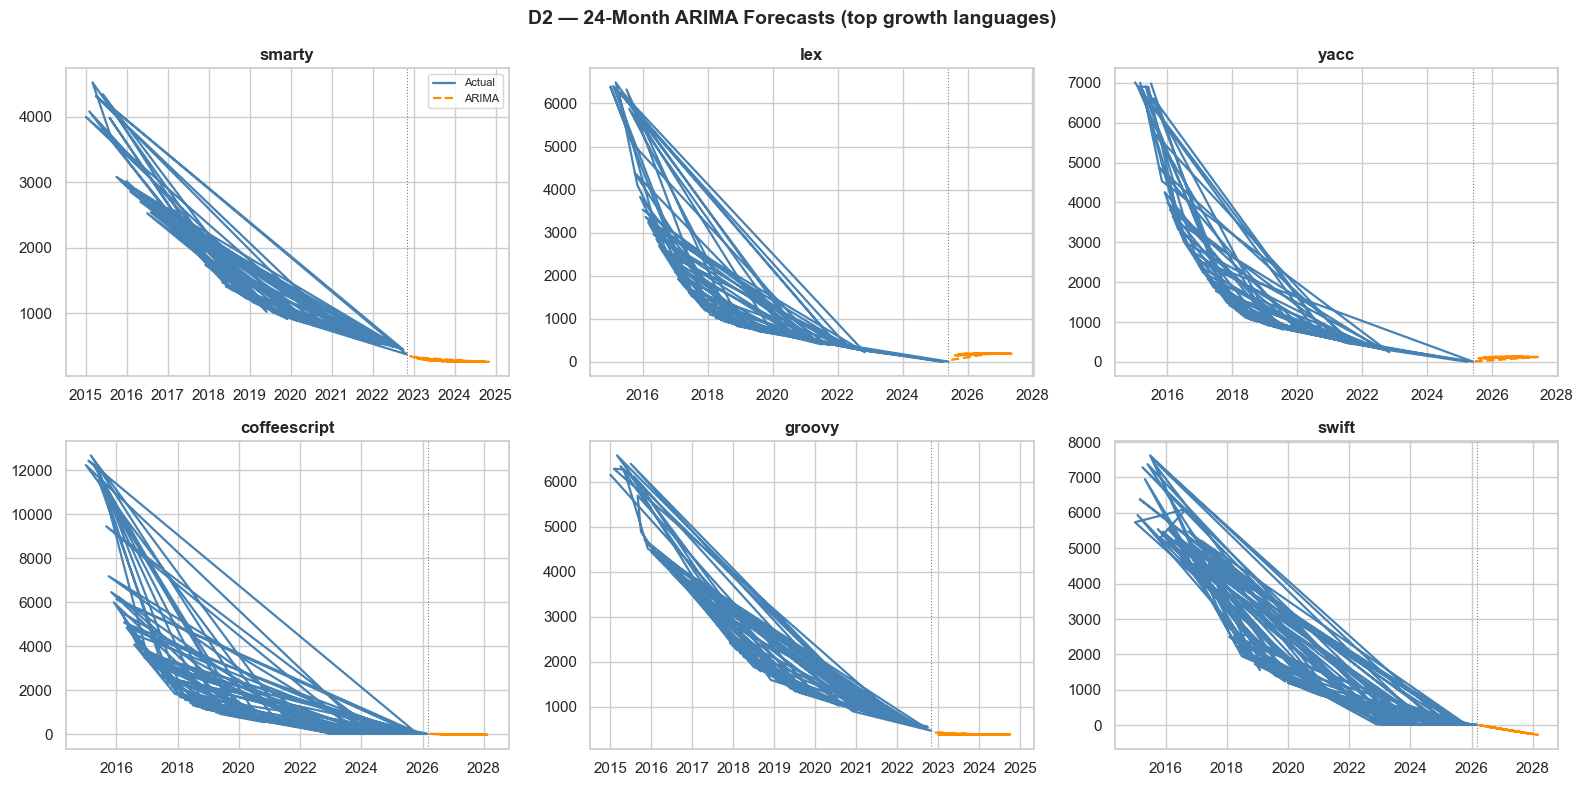

→ 30 languages forecast  |  24 months forward from 2026-03


In [4]:
# Show ARIMA forecasts for top-6 languages
fc_delta = (
    d2_forecasts[d2_forecasts['is_forecast']].groupby('language')['arima_yhat'].mean()
    - d2_forecasts[~d2_forecasts['is_forecast']].groupby('language')['actual'].mean()
).sort_values(ascending=False)
top6 = fc_delta.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, lang in enumerate(top6):
    ax = axes[idx]
    sub  = d2_forecasts[d2_forecasts['language'] == lang]
    hist = sub[~sub['is_forecast']]
    fc   = sub[sub['is_forecast']]
    ax.plot(hist['date'], hist['actual'],  color='steelblue',  lw=1.6, label='Actual')
    ax.plot(fc['date'],   fc['arima_yhat'], color='darkorange', lw=1.6, ls='--', label='ARIMA')
    ax.axvline(hist['date'].max(), color='grey', lw=0.8, ls=':')
    ax.set_title(lang, fontweight='bold')
    if idx == 0: ax.legend(fontsize=8)

plt.suptitle('D2 — 24-Month ARIMA Forecasts (top growth languages)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_d2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ {d2_forecasts["language"].nunique()} languages forecast  |  '
      f'24 months forward from {d2_forecasts[~d2_forecasts["is_forecast"]]["date"].max().strftime("%Y-%m")}')

---
## Part 3 — D3: Technology Migration

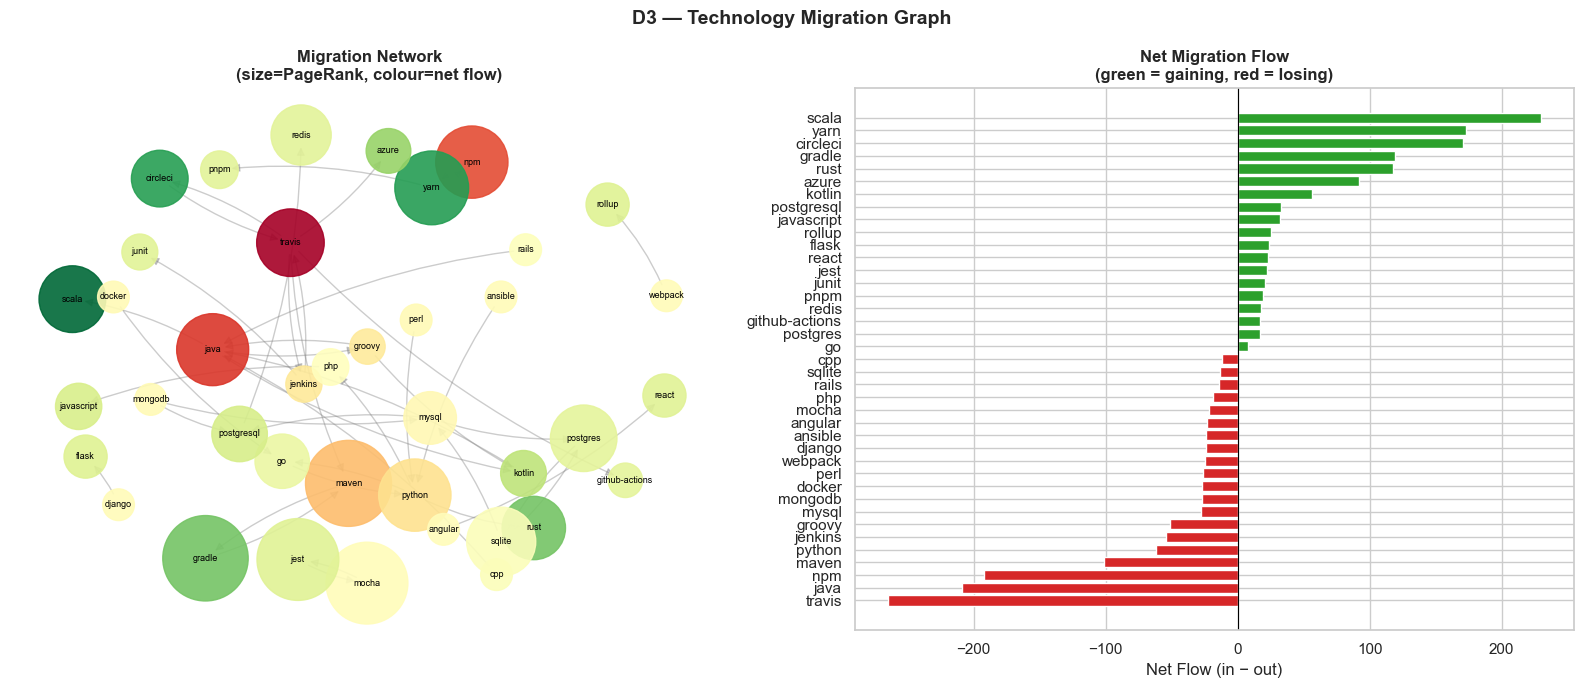

→ 42 migration edges  |  39 technology nodes
→ Top migration destinations: [['scala', 230], ['yarn', 173], ['circleci', 171]]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- NetworkX graph ---
G = nx.DiGraph()
for _, row in d3_edges.iterrows():
    G.add_edge(row['from_tech'], row['to_tech'], weight=row['migration_count'])

node_pr = d3_nodes.set_index('tech')['pagerank'].to_dict()
node_nf = d3_nodes.set_index('tech')['net_flow'].to_dict()

node_sizes = [max(200, node_pr.get(n, 0) * 60000) for n in G.nodes]
min_nf, max_nf = min(node_nf.values()), max(node_nf.values())
norm_nf = [(node_nf.get(n, 0) - min_nf) / (max_nf - min_nf + 1e-9) for n in G.nodes]
node_colors = [plt.cm.RdYlGn(v) for v in norm_nf]

pos = nx.spring_layout(G, k=2.5, seed=42)
ax = axes[0]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6.5, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='grey',
                       arrows=True, arrowsize=12,
                       connectionstyle='arc3,rad=0.1', ax=ax)
ax.set_title('Migration Network\n(size=PageRank, colour=net flow)', fontweight='bold')
ax.axis('off')

# --- Net flow bar ---
ax = axes[1]
ns = d3_nodes.sort_values('net_flow')
colors = ['#d62728' if v < 0 else '#2ca02c' for v in ns['net_flow']]
ax.barh(ns['tech'], ns['net_flow'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Net Flow (in − out)')
ax.set_title('Net Migration Flow\n(green = gaining, red = losing)', fontweight='bold')

plt.suptitle('D3 — Technology Migration Graph', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_d3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ {len(d3_edges)} migration edges  |  {len(d3_nodes)} technology nodes')
top_dest = d3_nodes.nlargest(3, 'net_flow')[['tech', 'net_flow']].values.tolist()
print(f'→ Top migration destinations: {top_dest}')

---
## Part 4 — D4 + D5: Developer Network

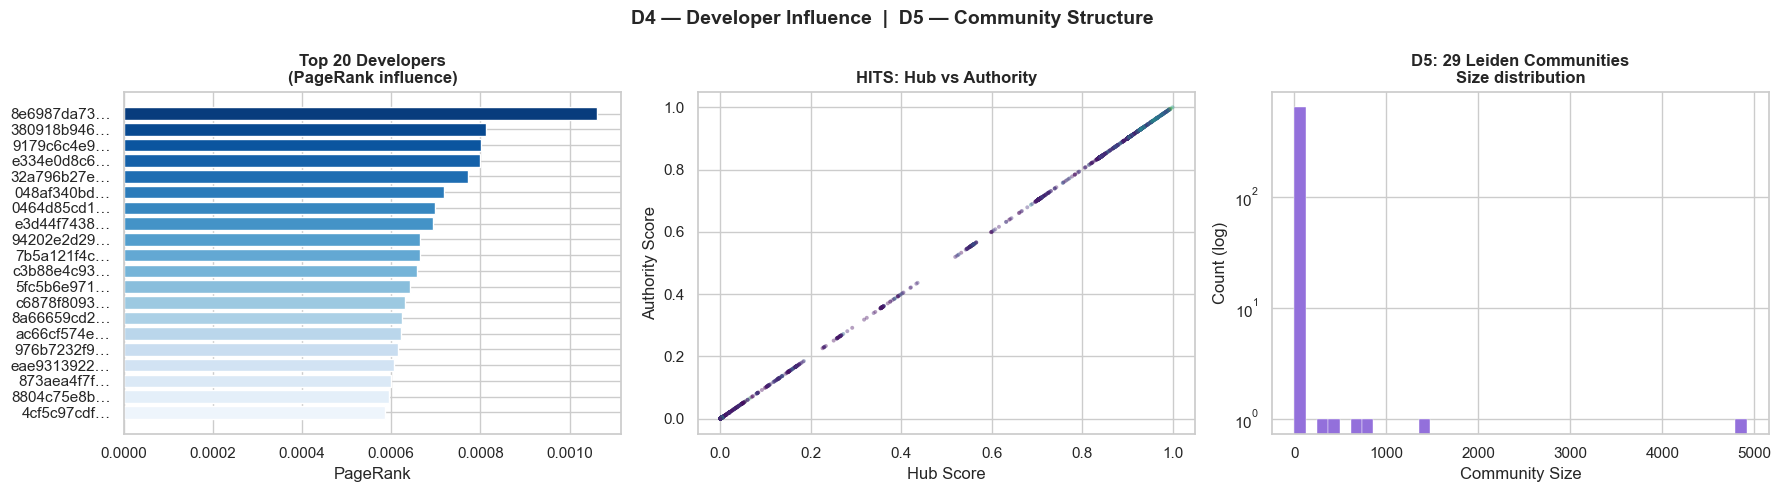

→ D4: 10,000 developers  |  mean degree=242.6
→ D5: 652 communities  |  largest=4,915 members


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- D4: Top PageRank ---
ax = axes[0]
top20 = d4_pagerank.nlargest(20, 'pagerank')
ax.barh(
    [f'{r[:10]}…' for r in top20['dev_id']],
    top20['pagerank'],
    color=sns.color_palette('Blues_r', 20),
)
ax.invert_yaxis()
ax.set_xlabel('PageRank')
ax.set_title('Top 20 Developers\n(PageRank influence)', fontweight='bold')

# --- D4: Hub vs Authority ---
ax = axes[1]
ax.scatter(d4_pagerank['hub_score'], d4_pagerank['auth_score'],
           c=np.log1p(d4_pagerank['total_commits']), cmap='viridis',
           alpha=0.4, s=8, edgecolors='none')
ax.set_xlabel('Hub Score')
ax.set_ylabel('Authority Score')
ax.set_title('HITS: Hub vs Authority', fontweight='bold')

# --- D5: Community size distribution ---
ax = axes[2]
comm_sizes = d5_comms.groupby('community_id').size().sort_values(ascending=False)
ax.hist(comm_sizes.values, bins=40, color='mediumpurple',
        edgecolor='white', linewidth=0.3, log=True)
ax.set_xlabel('Community Size')
ax.set_ylabel('Count (log)')
ax.set_title(f'D5: {comm_sizes.nunique()} Leiden Communities\nSize distribution',
             fontweight='bold')

plt.suptitle('D4 — Developer Influence  |  D5 — Community Structure',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/report_d4d5.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'→ D4: {len(d4_pagerank):,} developers  |  '
      f'mean degree={d4_pagerank["degree"].mean():.1f}')
print(f'→ D5: {d5_comms["community_id"].nunique()} communities  |  '
      f'largest={comm_sizes.iloc[0]:,} members')

---
## Summary Statistics

In [7]:
summary = pd.DataFrame([
    {'Deliverable': 'D1 Monthly',    'Rows': f'{len(d1_monthly):,}',
     'Key fact': f'{d1_monthly["language"].nunique()} languages, '
                 f'{d1_monthly["date"].min().year}–{d1_monthly["date"].max().year}'},
    {'Deliverable': 'D1 Clusters',   'Rows': f'{len(d1_clusters):,}',
     'Key fact': f'{d1_clusters["cluster"].nunique()} KMeans clusters (silhouette 0.9008)'},
    {'Deliverable': 'D2 Forecasts',  'Rows': f'{len(d2_forecasts):,}',
     'Key fact': f'{d2_forecasts["language"].nunique()} languages × 24-month ARIMA forward'},
    {'Deliverable': 'D3 Edges',      'Rows': f'{len(d3_edges):,}',
     'Key fact': f'min weight {d3_edges["migration_count"].min()}, max {d3_edges["migration_count"].max()}'},
    {'Deliverable': 'D3 Nodes',      'Rows': f'{len(d3_nodes):,}',
     'Key fact': f'Top destination: {d3_nodes.nlargest(1, "net_flow")["tech"].iloc[0]}'},
    {'Deliverable': 'D4 PageRank',   'Rows': f'{len(d4_pagerank):,}',
     'Key fact': f'Mean degree {d4_pagerank["degree"].mean():.1f}, '
                 f'max commits {d4_pagerank["total_commits"].max():,}'},
    {'Deliverable': 'D5 Communities','Rows': f'{len(d5_comms):,}',
     'Key fact': f'{d5_comms["community_id"].nunique()} Leiden communities detected'},
])

summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Deliverable,Rows,Key fact
D1 Monthly,"43,016","468 languages, 2015–2026"
D1 Clusters,468,6 KMeans clusters (silhouette 0.9008)
D2 Forecasts,"4,191",30 languages × 24-month ARIMA forward
D3 Edges,42,"min weight 12, max 387"
D3 Nodes,39,Top destination: scala
D4 PageRank,"10,000","Mean degree 242.6, max commits 5,711,842"
D5 Communities,"10,000",652 Leiden communities detected
